## 1. Setup

Importing the libraries needed for data loading, cleaning, and visualization.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
%matplotlib inline

## 2. Load Data

Reading in the raw Bengaluru house price dataset.

In [4]:
df = pd.read_csv("../data/bengaluru_house_data.csv")
df.head()

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00


## 3. Initial Data Overview

Checking dataset shape, column data types, and missing values before any cleaning.

In [5]:
print(df.shape)
df.info()
df.isnull().sum()

(13320, 9)
<class 'pandas.DataFrame'>
RangeIndex: 13320 entries, 0 to 13319
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   area_type     13320 non-null  str    
 1   availability  13320 non-null  str    
 2   location      13319 non-null  str    
 3   size          13304 non-null  str    
 4   society       7818 non-null   str    
 5   total_sqft    13320 non-null  str    
 6   bath          13247 non-null  float64
 7   balcony       12711 non-null  float64
 8   price         13320 non-null  float64
dtypes: float64(3), str(6)
memory usage: 936.7 KB


area_type          0
availability       0
location           1
size              16
society         5502
total_sqft         0
bath              73
balcony          609
price              0
dtype: int64

## 4. Data Cleaning

Addressing missing values, inconsistent `total_sqft` formats, and extracting a numeric BHK value from `size`.

In [6]:
#Drop society (94% missing, not usable):
df = df.drop('society', axis=1)
#Drop rows with missing location and size (very few rows, safe to drop):
df = df.dropna(subset=['location', 'size'])
#Fill bath and balcony with median (small number missing):
df['bath'] = df['bath'].fillna(df['bath'].median())
df['balcony'] = df['balcony'].fillna(df['balcony'].median())
#Extract numeric BHK from size (e.g. "2 BHK" → 2, "4 Bedroom" → 4):
df['bhk'] = df['size'].apply(lambda x: int(x.split(' ')[0]))
#Fix total_sqft (has ranges like "1200-1400" and some unit strings):
def convert_sqft(x):
    try:
        return float(x)
    except:
        if '-' in x:
            parts = x.split('-')
            return (float(parts[0]) + float(parts[1])) / 2
        return None

df['total_sqft'] = df['total_sqft'].apply(convert_sqft)
df = df.dropna(subset=['total_sqft'])
#Sanity check after cleaning:
print(df.shape)
df.isnull().sum()
df.head()

(13257, 9)


,area_type,availability,location,size,total_sqft,bath,balcony,price,bhk
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,1056.0,2.0,1.0,39.07,2
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,2600.0,5.0,3.0,120.00,4
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,1440.0,2.0,3.0,62.00,3
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,1521.0,3.0,1.0,95.00,3
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,1200.0,2.0,1.0,51.00,2


## 5. Feature Engineering

Creating `price_per_sqft` — the key metric for comparing value across localities — and checking for outliers.

In [7]:
# Create price_per_sqft (note: price is in lakhs, so this needs unit handling):
df['price_per_sqft'] = (df['price'] * 100000) / df['total_sqft']
df[['location', 'total_sqft', 'bhk', 'price', 'price_per_sqft']].head()

# Check for outliers (common issue: sqft-per-bedroom too small to be real)
# A realistic bedroom is at least ~300 sqft
df[df['total_sqft'] / df['bhk'] < 300].shape

#Check price_per_sqft distribution for extreme outliers:
df['price_per_sqft'].describe()

count    1.325700e+04
mean     7.912825e+03
std      1.064976e+05
min      2.678298e+02
25%      4.271186e+03
50%      5.438596e+03
75%      7.313318e+03
max      1.200000e+07
Name: price_per_sqft, dtype: float64

## 6. Outlier Removal

Removing rows with unrealistic sqft-per-bedroom and extreme price-per-sqft outliers within each locality.

In [8]:
# Remove unrealistic sqft-per-bedroom rows:
df = df[~(df['total_sqft'] / df['bhk'] < 300)]
print(df.shape)
#Remove price-per-sqft outliers within each locality (not globally — a fair price in one area can look like an outlier city-wide, so we filter per-location using mean ± 1 standard deviation):
def remove_pps_outliers(df):
    df_out = pd.DataFrame()
    for key, subdf in df.groupby('location'):
        m = subdf['price_per_sqft'].mean()
        st = subdf['price_per_sqft'].std()
        reduced_df = subdf[(subdf['price_per_sqft'] > (m - st)) & (subdf['price_per_sqft'] <= (m + st))]
        df_out = pd.concat([df_out, reduced_df], ignore_index=True)
    return df_out

df = remove_pps_outliers(df)
print(df.shape)
#Recheck the distribution:
df['price_per_sqft'].describe()

(12513, 10)
(9642, 10)


count     9642.000000
mean      5744.577931
std       2587.666963
min       1250.000000
25%       4252.336449
50%       5181.818182
75%       6421.400092
max      35000.000000
Name: price_per_sqft, dtype: float64

## 7. Univariate Analysis

Distribution of price, price per sqft, and BHK across listings.

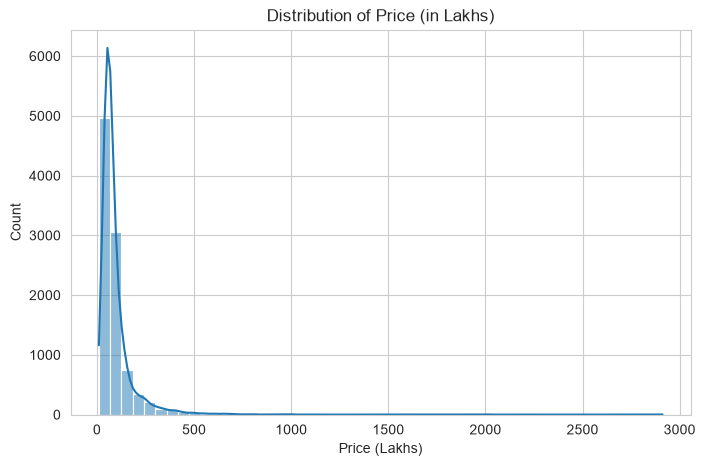

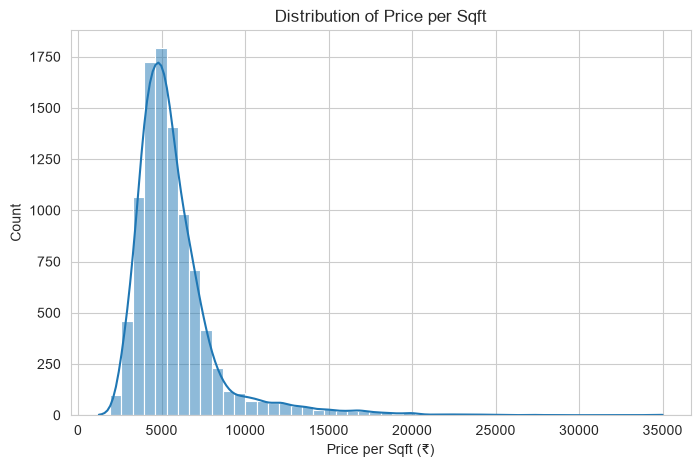

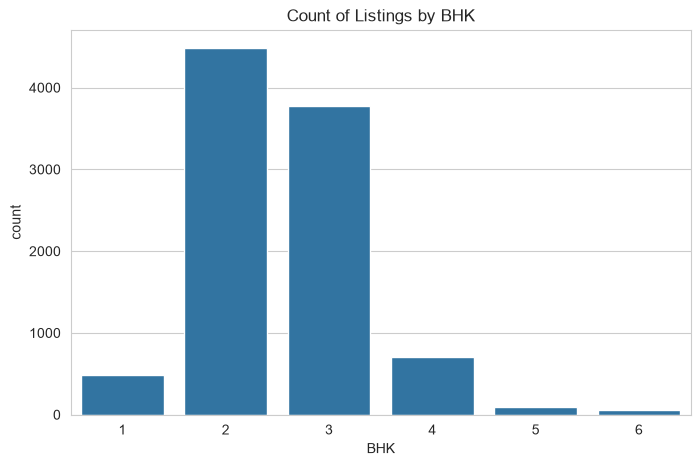

In [9]:
#Chart 1 — Price distribution:
plt.figure(figsize=(8,5))
sns.histplot(df['price'], bins=50, kde=True)
plt.title('Distribution of Price (in Lakhs)')
plt.xlabel('Price (Lakhs)')
plt.savefig('../images/price_distribution.png', bbox_inches='tight')
plt.show()
#Chart 2 — Price per sqft distribution:
plt.figure(figsize=(8,5))
sns.histplot(df['price_per_sqft'], bins=50, kde=True)
plt.title('Distribution of Price per Sqft')
plt.xlabel('Price per Sqft (₹)')
plt.savefig('../images/price_per_sqft_distribution.png', bbox_inches='tight')
plt.show()
#Chart 3 — BHK count:
plt.figure(figsize=(8,5))
sns.countplot(x='bhk', data=df[df['bhk'] <= 6])
plt.title('Count of Listings by BHK')
plt.xlabel('BHK')
plt.savefig('../images/bhk_countplot.png', bbox_inches='tight')
plt.show()

## 8. Locality-Level Analysis

Comparing price per sqft across Bengaluru's localities to identify premium and affordable areas.

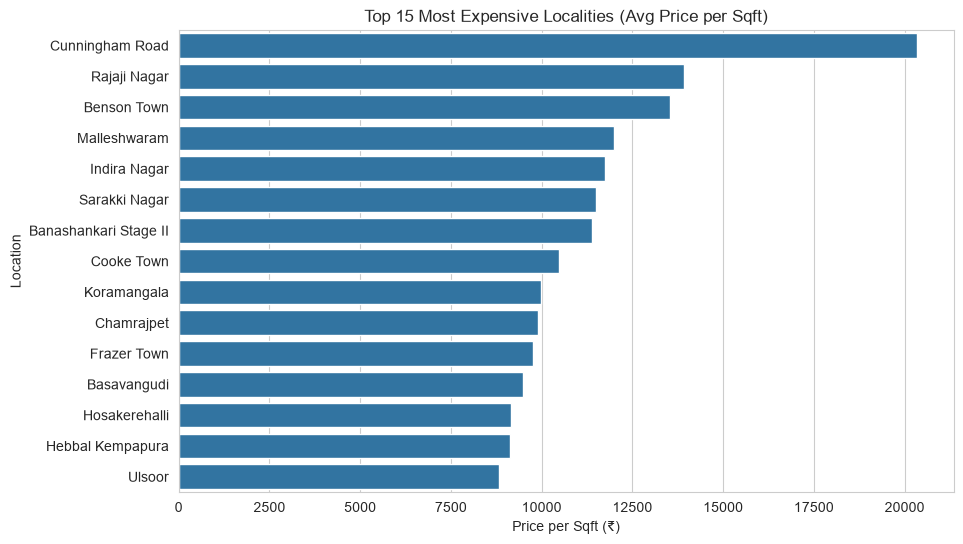

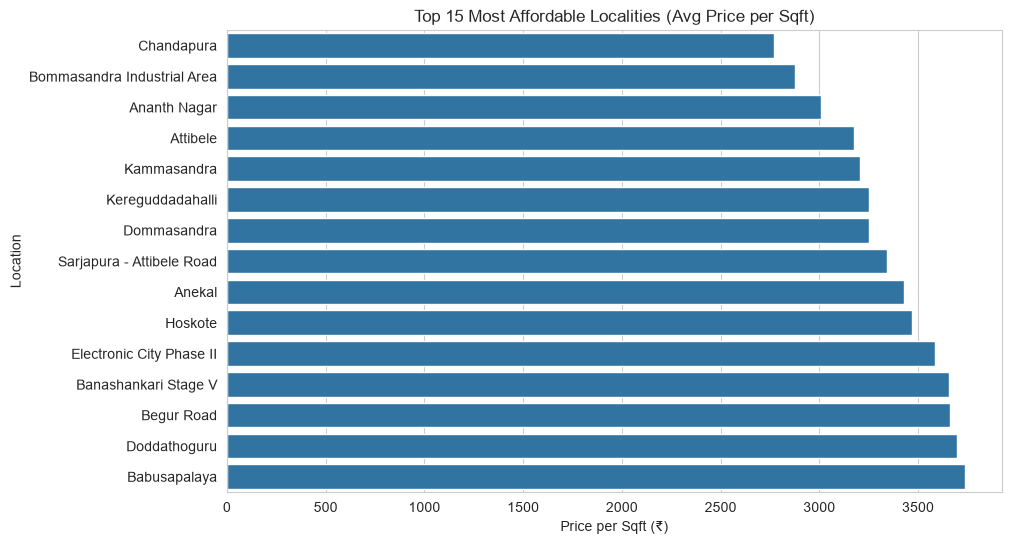

In [12]:
#Filter to localities with enough listings to be statistically meaningful:
location_counts = df['location'].value_counts()
locations_with_min_listings = location_counts[location_counts >= 10].index
df_filtered = df[df['location'].isin(locations_with_min_listings)]
#Top 15 most expensive localities:
top_expensive = df_filtered.groupby('location')['price_per_sqft'].mean().sort_values(ascending=False).head(15)

plt.figure(figsize=(10,6))
sns.barplot(x=top_expensive.values, y=top_expensive.index)
plt.title('Top 15 Most Expensive Localities (Avg Price per Sqft)')
plt.xlabel('Price per Sqft (₹)')
plt.ylabel('Location')
plt.savefig('../images/top_expensive_localities.png', bbox_inches='tight')
plt.show()
#Top 15 most affordable localities:
top_affordable = df_filtered.groupby('location')['price_per_sqft'].mean().sort_values(ascending=True).head(15)

plt.figure(figsize=(10,6))
sns.barplot(x=top_affordable.values, y=top_affordable.index)
plt.title('Top 15 Most Affordable Localities (Avg Price per Sqft)')
plt.xlabel('Price per Sqft (₹)')
plt.ylabel('Location')
plt.savefig('../images/top_affordable_localities.png', bbox_inches='tight')
plt.show()

In [13]:
#calculate the actual premium:
city_median = df['price_per_sqft'].median()
top_locality_price = top_expensive.iloc[0]
premium_pct = ((top_locality_price - city_median) / city_median) * 100

print(f"City median price/sqft: ₹{city_median:.0f}")
print(f"{top_expensive.index[0]} price/sqft: ₹{top_locality_price:.0f}")
print(f"Premium: {premium_pct:.1f}%")

City median price/sqft: ₹5182
Cunningham Road price/sqft: ₹20336
Premium: 292.4%


## 9. Bivariate & Multivariate Analysis

Relationships between price, sqft, BHK, and bathrooms.

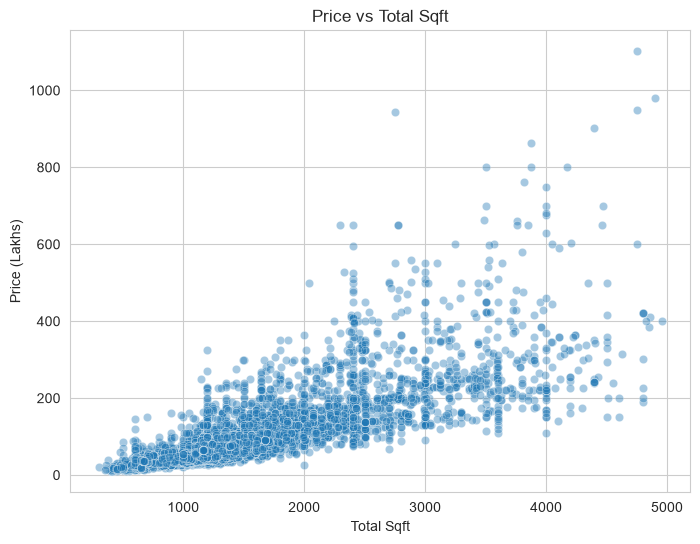

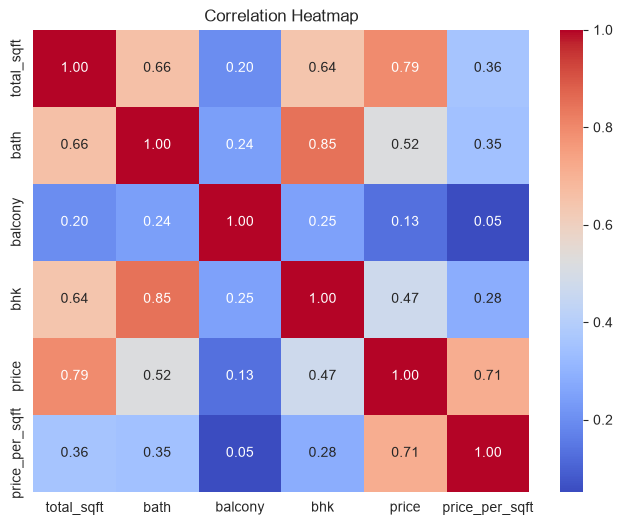

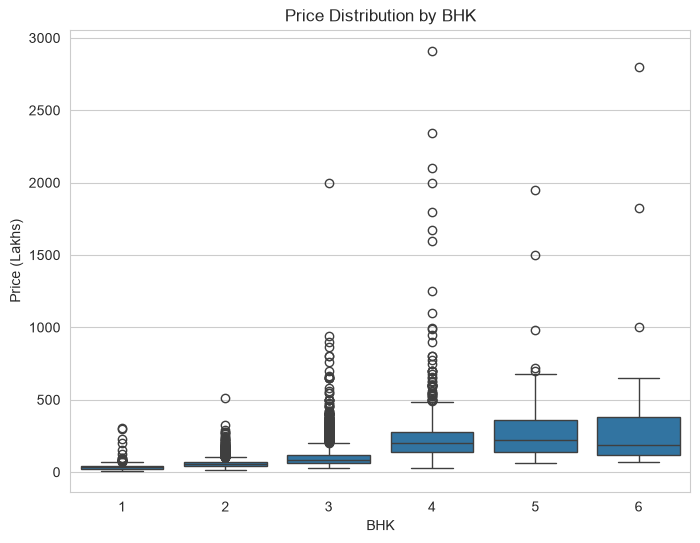

In [14]:
#Chart 1 — Price vs Total Sqft:
plt.figure(figsize=(8,6))
sns.scatterplot(x='total_sqft', y='price', data=df[df['total_sqft'] < 5000], alpha=0.4)
plt.title('Price vs Total Sqft')
plt.xlabel('Total Sqft')
plt.ylabel('Price (Lakhs)')
plt.savefig('../images/price_vs_sqft.png', bbox_inches='tight')
plt.show()
#Chart 2 — Correlation heatmap:
plt.figure(figsize=(8,6))
corr = df[['total_sqft', 'bath', 'balcony', 'bhk', 'price', 'price_per_sqft']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.savefig('../images/correlation_heatmap.png', bbox_inches='tight')
plt.show()
#Chart 3 — Price by BHK (boxplot):
plt.figure(figsize=(8,6))
sns.boxplot(x='bhk', y='price', data=df[df['bhk'] <= 6])
plt.title('Price Distribution by BHK')
plt.xlabel('BHK')
plt.ylabel('Price (Lakhs)')
plt.savefig('../images/price_by_bhk.png', bbox_inches='tight')
plt.show()

## 10. Key Insights

- **Cunningham Road** commands a **292% premium** over the city median price per sqft (₹20,336 vs ₹5,182), making it the most expensive locality in the dataset.
- The most affordable localities (Chandapura, Bommasandra Industrial Area) sit near ₹2,700–2,900/sqft  roughly 45-48% of the city median, reflecting outer/industrial-zone pricing.
- `total_sqft` is the strongest single predictor of price (correlation: 0.79), followed by `bath` count (0.52).
- `bath` and `bhk` are highly correlated (0.85)  larger homes scale bathrooms and bedrooms together, a useful note for any future modeling to avoid redundant features.
- Price distribution is heavily right-skewed: most homes are under ₹100L, but a small number of luxury 4-6 BHK listings (up to ₹2,900L) pull the tail significantly.
- Price per sqft variance within the same locality was reduced substantially after outlier removal (max dropped from ₹1.2 crore/sqft to ₹35,000/sqft), showing how much raw listing data needed cleaning before it was trustworthy.